# Part 8: Symbolic Regression

In [2]:
import numpy as np
import sympy
import matplotlib.pyplot as plt
import hls4ml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_curve, auc, accuracy_score
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import fetch_openml

2026-04-06 15:46:36.962651: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Load the LHC jet tagging dataset

In [3]:
data = fetch_openml('hls4ml_lhc_jets_hlf')
X, Y = data['data'].to_numpy(), data['target'].to_numpy()
print(data['feature_names'])
print(X.shape, Y.shape)
print(Y[:10])

LE = LabelEncoder()
Y = LE.fit_transform(Y)
Y = to_categorical(Y, 5)

Y = 2 * Y - 1
print(Y[:10])

/home/yvan/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


['zlogz', 'c1_b0_mmdt', 'c1_b1_mmdt', 'c1_b2_mmdt', 'c2_b1_mmdt', 'c2_b2_mmdt', 'd2_b1_mmdt', 'd2_b2_mmdt', 'd2_a1_b1_mmdt', 'd2_a1_b2_mmdt', 'm2_b1_mmdt', 'm2_b2_mmdt', 'n2_b1_mmdt', 'n2_b2_mmdt', 'mass_mmdt', 'multiplicity']
(830000, 16) (830000,)
['g' 'w' 't' 'z' 'w' 'w' 't' 'g' 'z' 'g']
[[ 1. -1. -1. -1. -1.]
 [-1. -1. -1.  1. -1.]
 [-1. -1.  1. -1. -1.]
 [-1. -1. -1. -1.  1.]
 [-1. -1. -1.  1. -1.]
 [-1. -1. -1.  1. -1.]
 [-1. -1.  1. -1. -1.]
 [ 1. -1. -1. -1. -1.]
 [-1. -1. -1. -1.  1.]
 [ 1. -1. -1. -1. -1.]]


In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.5, random_state=123)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

# PySR (or any genetic programming based SR) not happy with too many training data
X_train = X_train[:8000]
Y_train = Y_train[:8000]

print('X_train.shape: ' + str(X_train.shape))
print('Y_train.shape: ' + str(Y_train.shape))
print('X_test.shape: ' + str(X_test.shape))
print('Y_test.shape: ' + str(Y_test.shape))

X_train.shape: (8000, 16)
Y_train.shape: (8000, 5)
X_test.shape: (415000, 16)
Y_test.shape: (415000, 5)


## Perform SR with PySR (if installed)

If you want to run `PySR` (a genetic programming-based symbolic regression software), please see https://github.com/MilesCranmer/PySR for installation and intructions.

Below is an example configuration script to run training in `PySR`, where one can specify the allowed primitive functions `unary_operators` `binary_operators` (e.g. `+`, `*`, `sin`) and constraints `complexity_of_operators` `constraints` `nested_constraints` in the equation seacrhing. The training results will be stored in a `.pkl` file that contains the final equations selected by the training strategy `model_selection`.

We also provide an already trained PySR model `sr/example.pkl` in the following sections for demonstrating the HLS implementation.

In [5]:
from pysr import PySRRegressor

!export JULIA_NUM_THREADS=32

model_pysr = PySRRegressor(
    model_selection='accuracy',
    niterations=40,
    timeout_in_seconds=60 * 60 * 1,
    maxsize=40,
    select_k_features=6,
    binary_operators=['+', '-', '*'],
    unary_operators=['sin', 'sc(x)=sin(x)*cos(x)'],
    complexity_of_operators={'+': 1, '-': 1, '*': 1, 'sin': 1, 'sc': 1},
    constraints={'sin': 20, 'sc': 20},
    nested_constraints={'sin': {'sin': 0, 'sc': 0}, 'sc': {'sin': 0, 'sc': 0}},
    extra_sympy_mappings={'sc': lambda x: sympy.sin(x) * sympy.cos(x)},
    loss='L2MarginLoss()',  # (1 - y*y')^2
)

In [6]:
!python3 -m pysr install

[ Info: Julia version info
Julia Version 1.10.2
Commit bd47eca2c8a (2024-03-01 10:14 UTC)
Build Info:
  Official https://julialang.org/ release
Platform Info:
  OS: Linux (x86_64-linux-gnu)
      Ubuntu 22.04.5 LTS
  uname: Linux 6.8.0-101-generic #101~22.04.1-Ubuntu SMP PREEMPT_DYNAMIC Wed Feb 11 13:19:54 UTC  x86_64 x86_64
  CPU: AMD Ryzen 5 5600X 6-Core Processor: 
                 speed         user         nice          sys         idle          irq
       #1-12  3551 MHz    6627052 s       7390 s    1644995 s  389127529 s          0 s
  Memory: 46.96377944946289 GB (31423.625 MB free)
  Uptime: 3.31866659e6 sec
  Load Avg:  1.57  1.85  1.06
  WORD_SIZE: 64
  LIBM: libopenlibm
  LLVM: libLLVM-15.0.7 (ORCJIT, znver3)
Threads: 1 default, 0 interactive, 1 GC (on 12 virtual cores)
Environment:
  JULIA_CONDAPKG_BACKEND_BACKUP = 
  JULIA_CONDAPKG_BACKEND = System
  JULIA_LOAD_PATH = @:@hls4ml-tutorial:@stdlib
  JULIA_LOAD_PATH_BACKUP = 
  JULIA_DEPOT_PATH_BACKUP = 
  JULIA_PROJECT_BACKU

In [ ]:
model_pysr.fit(X_train, Y_train)

/home/yvan/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/pysr/sr.py:1346: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Using features ['x2' 'x3' 'x6' 'x8' 'x14' 'x15']
Compiling Julia backend...


/home/yvan/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/pysr/julia_helpers.py:208: UserWarning: Your system's Python library is static (e.g., conda), so precompilation will be turned off. For a dynamic library, try using `pyenv` and installing with `--enable-shared`: https://github.com/pyenv/pyenv/blob/master/plugins/python-build/README.md#building-with---enable-shared.
  warnings.warn(


## Prepare symbolic expressions in strings first

We provide a trained model for the HLS demonstration.

**If you have `PySR` installed**, you can directly load the trained expressions from the output file `sr/example.pkl`.
`PySR` allows custom functions to be defined, such as sc(x):=sin(x)*cos(x) in this example, they need to be re-defined through `extra_sympy_mappings` and a new `sympy` class when retrieving the equations for evaluation.

In [7]:
from pysr import PySRRegressor

model_pysr = PySRRegressor.from_file('sr/example.pkl')
with sympy.evaluate(True):
    for i in range(5):
        print('Tagger {} = '.format(i) + str(model_pysr.sympy()[i]) + '\n------------------------------------------')

# Re-write custom operator defined from PySR config: sc(x) = sin(x)*cos(x)
model_pysr.set_params(extra_sympy_mappings={"sc": lambda x: sympy.sin(x) * sympy.cos(x)})
model_pysr.refresh()


class sc(sympy.Function):
    pass

Checking if sr/example.pkl exists...
Loading model from sr/example.pkl
Tagger 0 = -0.1630426*(sc(-0.75052315) - 0.84283006)*sc(2*x14 - 1.03665108) - sin(x14 - (0.9237657 - 0.11933863*x3)*(-x15 + 2*x2 - 0.3817056) + 1.761264957)
------------------------------------------
Tagger 1 = (-(0.5822144*sc(0.83811*x14) - 0.5324657)*(sc(0.3923645*x2) - 0.63548696) + sc(x14 - 0.3923645*x15 + x3 + 0.51168373))*(0.561041303633489*sin(x15) - 0.47277835) - 0.84055585
------------------------------------------
Tagger 2 = 0.49239117*(sc(x3) + sc(x15 + 0.76784414*x3))*(sc(-0.13417026) + sc(0.5180547) + sc(x2)) - sin(x14 + 0.25715914*x15*x3 - x2 - x3 + 0.66443527)
------------------------------------------
Tagger 3 = 0.41071504*(0.9298677 - sin(0.59376544*x15))*(sc(x14) + 5.2546763*sc(0.71913457 - x3))*(-sc(2*x3) + sc(5.2546763*x14 + x3 + 0.77032656) + 0.32492808) - 0.863786752431664
------------------------------------------
Tagger 4 = (1.0745832 - sc(-x14 - 0.4094719))*(-0.15737492*x15 - sc(x14 - 4.2594

AttributeError: 'PySRRegressor' object has no attribute 'dimensional_constraint_penalty'

There are two options for evaluating math functions in `hls4ml`, one is using the standard HLS math library (`func`), another one is using approximation with user-defined lookup tables (`func_lut`) for resources saving. We will define the lookup tables (table range and size) for `func_lut` later.

We have the equations in the `sympy` format, now convert them into strings: `expr` for using the standard functions and `expr_lut` for using the approximation with lookup tables. We will re-parse `expr` and `expr_lut` from strings in `sympy` format for the `hls4ml` converter.

In [ ]:
expr = []
expr_lut = []
for i in range(5):
    expr.append(str(model_pysr.sympy()[i]))
    expr_lut.append(expr[i].replace("sin", "sin_lut").replace("cos", "cos_lut"))

**If you don't have PySR installed**, you can also write your expressions directly in strings and parse in `sympy` format, which can then be fed to `hls4ml` converter. Here again, `expr` for using standard math library, `expr_lut` for using approximation with lookup tables.

In [9]:
# Expressions from 'sr/example.pkl'

# Expressions that will use Vivado math library
expr = [
    '-0.1630426*(sin(-0.75052315)*cos(-0.75052315) - 0.84283006)*sin(2*x14 - 1.03665108)*cos(2*x14 - 1.03665108) - sin(x14 - (0.9237657 - 0.11933863*x3)*(-x15 + 2*x2 - 0.3817056) + 1.761264957)',
    '(-(0.5822144*sin(0.83811*x14)*cos(0.83811*x14) - 0.5324657)*(sin(0.3923645*x2)*cos(0.3923645*x2) - 0.63548696) + sin(x14 - 0.3923645*x15 + x3 + 0.51168373)*cos(x14 - 0.3923645*x15 + x3 + 0.51168373))*(0.561041303633489*sin(x15) - 0.47277835) - 0.84055585',
    '0.49239117*(sin(x3)*cos(x3) + sin(x15 + 0.76784414*x3)*cos(x15 + 0.76784414*x3))*(sin(-0.13417026)*cos(-0.13417026) + sin(0.5180547)*cos(0.5180547) + sin(x2)*cos(x2)) - sin(x14 + 0.25715914*x15*x3 - x2 - x3 + 0.66443527)',
    '0.41071504*(0.9298677 - sin(0.59376544*x15))*(sin(x14)*cos(x14) + 5.2546763*sin(0.71913457 - x3)*cos(0.71913457 - x3))*(-sin(2*x3)*cos(2*x3) + sin(5.2546763*x14 + x3 + 0.77032656)*cos(5.2546763*x14 + x3 + 0.77032656) + 0.32492808) - 0.863786752431664',
    '(1.0745832 - sin(-x14 - 0.4094719)*cos(-x14 - 0.4094719))*(-0.15737492*x15 - sin(x14 - 4.2594776)*cos(x14 - 4.2594776) + sin(3*x14 - x3*(x14 - 4.1772995) - x3 + 3.087878)*cos(3*x14 - x3*(x14 - 4.1772995) - x3 + 3.087878) - 0.690204005690814)',
]
# Expressions that will use look-up table approximated math functions
expr_lut = []
for i in range(len(expr)):
    expr_lut.append(expr[i].replace("sin", "sin_lut").replace("cos", "cos_lut"))

## Then parse the strings to sympy expressions

Define the lookup tables for approximating math functions. The table range and size can be customized for each function to be approximated, they depend on how much precision can be compromised to save more resources.

In [10]:
from hls4ml.utils.symbolic_utils import init_pysr_lut_functions

# For functions approximated with look-up table, define the table range and size
function_definitions = [
    'sin_lut(x) = math_lut(sin, x, N=256, range_start=-8, range_end=8)',
    'cos_lut(x) = math_lut(cos, x, N=256, range_start=-8, range_end=8)',
]
init_pysr_lut_functions(init_defaults=True, function_definitions=function_definitions)

lut_functions = {
    'sin_lut': {'math_func': 'sin', 'range_start': -8, 'range_end': 8, 'table_size': 256},
    'cos_lut': {'math_func': 'cos', 'range_start': -8, 'range_end': 8, 'table_size': 256},
}

/home/yvan/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/pysr/julia_helpers.py:208: UserWarning: Your system's Python library is static (e.g., conda), so precompilation will be turned off. For a dynamic library, try using `pyenv` and installing with `--enable-shared`: https://github.com/pyenv/pyenv/blob/master/plugins/python-build/README.md#building-with---enable-shared.
  warnings.warn(


Parse `expr` and `expr_lut` to sympy expressions.

In [11]:
# Use sympy to parse strings into sympy expressions
for i in range(len(expr)):
    print('expr =\n' + expr[i])
    print("----------------------------------------")
    print('expr_LUT =\n' + expr_lut[i])
    print("========================================")
    expr[i] = sympy.parsing.sympy_parser.parse_expr(expr[i])
    expr_lut[i] = sympy.parsing.sympy_parser.parse_expr(expr_lut[i])

expr =
-0.1630426*(sin(-0.75052315)*cos(-0.75052315) - 0.84283006)*sin(2*x14 - 1.03665108)*cos(2*x14 - 1.03665108) - sin(x14 - (0.9237657 - 0.11933863*x3)*(-x15 + 2*x2 - 0.3817056) + 1.761264957)
----------------------------------------
expr_LUT =
-0.1630426*(sin_lut(-0.75052315)*cos_lut(-0.75052315) - 0.84283006)*sin_lut(2*x14 - 1.03665108)*cos_lut(2*x14 - 1.03665108) - sin_lut(x14 - (0.9237657 - 0.11933863*x3)*(-x15 + 2*x2 - 0.3817056) + 1.761264957)
expr =
(-(0.5822144*sin(0.83811*x14)*cos(0.83811*x14) - 0.5324657)*(sin(0.3923645*x2)*cos(0.3923645*x2) - 0.63548696) + sin(x14 - 0.3923645*x15 + x3 + 0.51168373)*cos(x14 - 0.3923645*x15 + x3 + 0.51168373))*(0.561041303633489*sin(x15) - 0.47277835) - 0.84055585
----------------------------------------
expr_LUT =
(-(0.5822144*sin_lut(0.83811*x14)*cos_lut(0.83811*x14) - 0.5324657)*(sin_lut(0.3923645*x2)*cos_lut(0.3923645*x2) - 0.63548696) + sin_lut(x14 - 0.3923645*x15 + x3 + 0.51168373)*cos_lut(x14 - 0.3923645*x15 + x3 + 0.51168373))*(0.56

Use `hls4ml.converters.convert_from_symbolic_expression` to convert sympy expressions and compile.

In [12]:
# Use hls4ml to convert sympy expressions into HLS model
hls_model = hls4ml.converters.convert_from_symbolic_expression(
    expr, n_symbols=16, output_dir='my-hls-test', precision='ap_fixed<16,6>', part='xcvu9p-flga2577-2-e'
)
hls_model.write()
hls_model.compile()

hls_model_lut = hls4ml.converters.convert_from_symbolic_expression(
    expr_lut,
    n_symbols=16,
    output_dir='my-hls-test-lut',
    precision='ap_fixed<16,6>',
    part='xcvu9p-flga2577-2-e',
    lut_functions=lut_functions,
)
hls_model_lut.write()
hls_model_lut.compile()

Writing HLS project
Done
Writing HLS project
Done
Writing HLS project
Done
Writing HLS project
Done


## Compare outputs: PySR vs HLS vs HLS(LUT)

In [13]:
test_vector = np.random.rand(1, 16) * 4 - 2
# print(model_pysr.predict(test_vector))
print(hls_model.predict(test_vector))
print(hls_model_lut.predict(test_vector))

[-0.42089844 -0.75683594 -0.89257812 -0.84863281 -1.22265625]
[-0.45800781 -0.75976562 -0.84570312 -0.86816406 -1.20996094]


## Compare performance on the dataset

In [14]:
# Y_pysr = model_pysr.predict(X_test)
Y_hls = hls_model.predict(X_test)
Y_hls_lut = hls_model_lut.predict(X_test)
# auc_pysr=[]
auc_hls = []
auc_hls_lut = []
for x, label in enumerate(LE.classes_):
    # fpr_pysr, tpr_pysr, _ = roc_curve(Y_test[:, x], Y_pysr[:, x])
    fpr_hls, tpr_hls, _ = roc_curve(Y_test[:, x], Y_hls[:, x])
    fpr_hls_lut, tpr_hls_lut, _ = roc_curve(Y_test[:, x], Y_hls_lut[:, x])
    # auc_pysr.append(auc(fpr_pysr, tpr_pysr))
    auc_hls.append(auc(fpr_hls, tpr_hls))
    auc_hls_lut.append(auc(fpr_hls_lut, tpr_hls_lut))

# print('PySR acc    = {0:.3f}'.format(accuracy_score(np.argmax(Y_test, axis=1), np.argmax(Y_pysr, axis=1))))
# print('PySR auc    = {0:.3f},{1:.3f},{2:.3f},{3:.3f},{4:.3f}'.format(auc_pysr[0],auc_pysr[1],auc_pysr[2],auc_pysr[3],auc_pysr[4]))
print('HLS acc     = {0:.3f}'.format(accuracy_score(np.argmax(Y_test, axis=1), np.argmax(Y_hls, axis=1))))
print(
    'HLS auc     = {0:.3f},{1:.3f},{2:.3f},{3:.3f},{4:.3f}'.format(
        auc_hls[0], auc_hls[1], auc_hls[2], auc_hls[3], auc_hls[4]
    )
)
print('HLS_LUT acc = {0:.3f}'.format(accuracy_score(np.argmax(Y_test, axis=1), np.argmax(Y_hls_lut, axis=1))))
print(
    'HLS_LUT auc = {0:.3f},{1:.3f},{2:.3f},{3:.3f},{4:.3f}'.format(
        auc_hls_lut[0], auc_hls_lut[1], auc_hls_lut[2], auc_hls_lut[3], auc_hls_lut[4]
    )
)

HLS acc     = 0.723
HLS auc     = 0.909,0.868,0.923,0.892,0.879
HLS_LUT acc = 0.721
HLS_LUT auc = 0.908,0.867,0.924,0.894,0.880


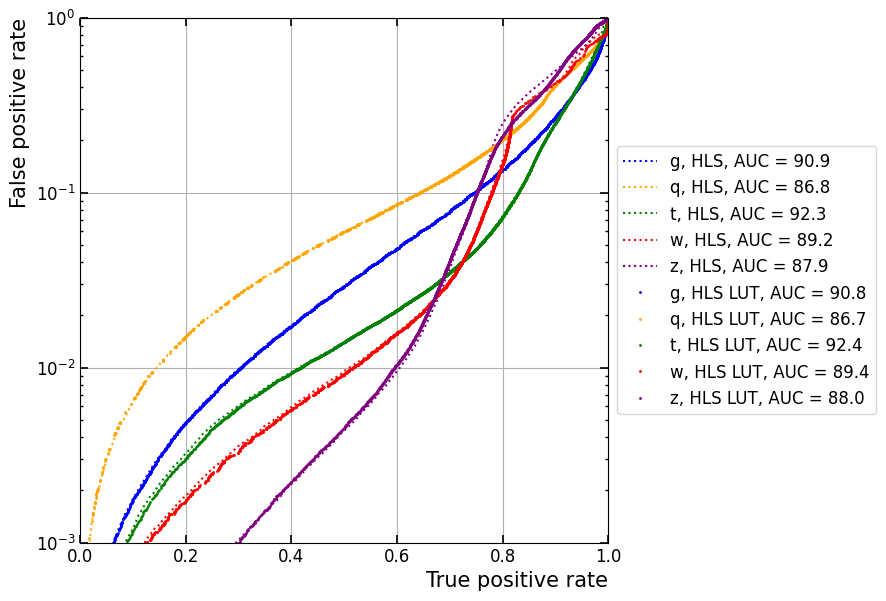

In [15]:
def plot_roc(y_test, y_pred, labels, model):
    color = ['blue', 'orange', 'green', 'red', 'purple']
    for x, label in enumerate(labels):
        fpr, tpr, _ = roc_curve(y_test[:, x], y_pred[:, x])
        if model == 'pysr':
            plt.plot(
                tpr,
                fpr,
                label='{0}, PySR, AUC = {1:.1f}'.format(label, auc(fpr, tpr) * 100.0),
                linestyle='solid',
                color=color[x],
                lw=1.5,
            )
        if model == 'hls':
            plt.plot(
                tpr,
                fpr,
                label='{0}, HLS, AUC = {1:.1f}'.format(label, auc(fpr, tpr) * 100.0),
                linestyle='dotted',
                color=color[x],
                lw=1.5,
            )
        if model == 'hls_lut':
            plt.plot(
                tpr,
                fpr,
                label='{0}, HLS LUT, AUC = {1:.1f}'.format(label, auc(fpr, tpr) * 100.0),
                linestyle='None',
                color=color[x],
                lw=1,
                marker='o',
                ms=1,
            )
    plt.semilogy()
    plt.xlabel('True positive rate', size=15, loc='right')
    plt.ylabel('False positive rate', size=15, loc='top')
    plt.tick_params(axis='both', which='major', direction='in', length=6, width=1.2, labelsize=12, right=True, top=True)
    plt.tick_params(axis='both', which='minor', direction='in', length=2, width=1, labelsize=12, right=True, top=True)
    plt.xlim(0, 1)
    plt.ylim(0.001, 1)
    plt.grid(True)
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)


plt.figure(figsize=(15, 15))
axes = plt.subplot(2, 2, 1)
# plot_roc(Y_test, Y_pysr, LE.classes_, 'pysr')
plot_roc(Y_test, Y_hls, LE.classes_, 'hls')
plot_roc(Y_test, Y_hls_lut, LE.classes_, 'hls_lut')

## Run synthesis from command line

In [16]:
!source ${XILINX_VITIS}/settings64.sh
!vitis_hls -f build_prj.tcl "reset=1 synth=1 csim=0 cosim=0 validation=0 export=0 vsynth=0"
!cat my-hls-test/myproject_prj/solution1/syn/report/myproject_csynth.rpt


****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2019.2 (64-bit)
  **** SW Build 3670227 on Oct 13 2022
  **** IP Build 2700528 on Thu Nov  7 00:09:20 MST 2019
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.

source /tools/Xilinx/Vitis_HLS/2022.2/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] Running '/tools/Xilinx/Vitis_HLS/2022.2/bin/unwrapped/lnx64.o/vitis_hls'
INFO: [HLS 200-10] For user 'yvan' on host 'yvan-B550-GAMING-X-V2' (Linux_x86_64 version 6.8.0-101-generic) on Mon Apr 06 15:50:19 CEST 2026
INFO: [HLS 200-10] On os Ubuntu 22.04.5 LTS
INFO: [HLS 200-10] In directory '/home/yvan/Bureau/Projekt/HLS4ML_PYNQ-Z1/hls4ml-tutorial'
ERROR [AP-1] Could not read script 'build_prj.tcl'.
INFO: [HLS 200-112] Total CPU user time: 0.53 seconds. Total CPU system time: 0.15 seconds. Total elapsed time: 2.38 seconds; peak allocated memory: 98.879 MB.
INFO: [Common 17-206] Exiting vitis_hls at Mon Apr  6 15:50:19 2026...
cat: my-hls-test/myproject_prj/solutio